# Counterfactual, Transportable Risk Prediction — Meta-Analysis Simulation

Extends `simulation.ipynb` to a **3-database meta-analysis** setting.

**Goal.** Estimate $\beta$ in $E(Y^0 \mid P, S=0) = \beta_0 + \beta_1 X_1 + \beta_2 X_2$ by:
1. Running the DR estimator independently on each of $K = 3$ databases,
2. Estimating $\widehat{\Sigma}^{(k)}$ via the sandwich variance,
3. Pooling across databases with **inverse-variance-weighted (IVW) fixed-effects meta-analysis**.

Each database has unique confounders, transportability covariates, treatment mechanisms, and outcome
coefficients. All three identify the same $\beta^* = (1.0,\; 0.9,\; 0.7)$.

**Simulation parts:**
- **Part A** — per-database DR: all $2^4 = 16$ misspecification patterns for each of the 3 databases.
- **Part B** — meta-analysis efficiency: compare individual-DB vs pooled estimates (all nuisances correct).
- **Part C** — meta-analysis robustness: one DB has misspecified nuisance, others are correct.

In [1]:
import numpy as np
import pandas as pd
from scipy.special import expit
from sklearn.linear_model import LinearRegression, LogisticRegression
import matplotlib.pyplot as plt
import itertools
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed

print('Imports OK')

Imports OK


## 1. Data-Generating Processes

All three databases identify $\beta^* = (1.0, 0.9, 0.7)$ via
$E(Y^0 \mid P, S=0) = 1 + 0.9\,X_1 + 0.7\,X_2$.

**A single dataset** is generated with $S \in \{0,1,2,3\}$ drawn from a **multinomial logistic** model with baseline $S=0$.  
Three pairwise sub-datasets are formed in the estimation step: sub-dataset $k$ = rows with $S \in \{0,k\}$, $S$ recoded to binary.  
The $S=0$ target population is **identical** across all three sub-datasets.

**IIA property** of multinomial logistic ensures the pairwise Bernoulli conditions hold exactly:
$$\Pr(S=k \mid S\in\{0,k\},\,X) = \text{expit}(\eta_k), \qquad k=1,2,3$$

**Intercept choice:** $a_k = -\tfrac{1}{2}(b_1^2+b_2^2+c_Z^2)$ so that $E[\exp(\eta_k)]=1$, giving $\Pr(S=k)\approx 25\%$ for each $k\in\{0,1,2,3\}$.

**Common risk predictors:** $X_1, X_2 \overset{\text{iid}}{\sim}\mathcal{N}(0,1)$.  
**Cohort-specific covariates:** $Z_k \sim \mathcal{N}(0,1)$, each $Z_k \perp (X_1,X_2)$.

| | DB 1 | DB 2 | DB 3 |
|---|---|---|---|
| Cohort covariate $Z_k$ | $Z_1$ | $Z_2$ | $Z_3$ |
| $\eta_k$ (log-odds vs $S=0$) | $-0.11+0.3X_1+0.2X_2+0.3Z_1$ | $-0.17+0.4X_1+0.3X_2+0.3Z_2$ | $-0.19+0.2X_1+0.5X_2+0.3Z_3$ |
| $\Pr(S=k)$ | $\approx 25\%$ | $\approx 25\%$ | $\approx 25\%$ |
| $L^{(k)}$ structure | $0.8X_1+0.2X_2+0.6Z_1$ | $0.5X_1+0.5X_2+0.4Z_2$ | $0.4X_1+0.8X_2+0.5Z_3$ |
| $\gamma^{(k)}$ (coef on $L$ in $Y$) | 0.50 | 0.80 | 0.60 |
| $\alpha_1^{(k)}$, $\alpha_2^{(k)}$ (direct $X$ in $Y$) | 0.50, 0.60 | 0.50, 0.30 | 0.66, 0.22 |
| $\alpha_Z^{(k)}$ (direct $Z_k$ in $Y$) | 0.30 | 0.20 | 0.40 |
| $c_Z^{(k)}=\alpha_Z+\gamma l_Z$ | 0.60 | 0.52 | 0.70 |
| Treatment effect $\tau^{(k)}$ | 1.4 | 1.8 | 2.2 |
| $A$ depends on | $X_1, L$ | $X_2, L$ | $X_1,X_2,L$ |
| $\alpha_0^{(k)}$ | calibrated | calibrated | calibrated |

**Analytical verification** ($Z_k \perp (X_1,X_2)$ → $E(Z_k\mid X_1,X_2)=0$):
- DB 1: $\beta_1^*=0.50+0.50\times0.8=0.90$; $\beta_2^*=0.60+0.50\times0.2=0.70$ ✓
- DB 2: $\beta_1^*=0.50+0.80\times0.5=0.90$; $\beta_2^*=0.30+0.80\times0.5=0.70$ ✓
- DB 3: $\beta_1^*=0.66+0.60\times0.4=0.90$; $\beta_2^*=0.22+0.60\times0.8=0.70$ ✓

**True $\psi^{(k)*}$ functions:**
$$\psi^{(1)*}=\alpha_0^{(1)}+0.9X_1+0.7X_2+0.60Z_1,\quad
  \psi^{(2)*}=\alpha_0^{(2)}+0.9X_1+0.7X_2+0.52Z_2,\quad
  \psi^{(3)*}=\alpha_0^{(3)}+0.9X_1+0.7X_2+0.70Z_3$$

**Misspecification:** omitting $Z_k$ from $\hat\rho$ is now meaningful — $Z_k$ enters $\eta_k$ with coefficient **0.3**, so $\hat\rho$ without $Z_k$ is materially wrong.

In [2]:
BETA_TRUE = np.array([1.0, 0.9, 0.7])

# Total Z^k → Y^0 effect per DB: c_Z^k = α_Z^k + γ^k · l_Z^k
# (analytically: slopes β1*, β2* don't involve c_Z because Z^k ⊥ X1,X2)
C_Z = {1: 0.60, 2: 0.52, 3: 0.70}

# Intercepts α₀^k calibrated in the cell below so that β₀* = 1.0 in each
# target population.  Initialised to 0.0; generate_db{1,2,3} use ALPHA0.get(k, 0.0)
# so they work before calibration (for calibration itself) and after.
ALPHA0 = {}

In [ ]:
# ── Unified DGP: S ∈ {0,1,2,3} via multinomial logistic ──────────────────────
#
# Selection: Pr(S=k|X) = exp(η_k) / (1 + exp(η1) + exp(η2) + exp(η3))
#            Pr(S=0|X) = 1         / (1 + ...)
# IIA → Pr(S=k | S∈{0,k}, X) = expit(η_k)  for k=1,2,3  (pairwise Bernoulli)
#
# Intercepts chosen so E[exp(η_k)] = 1, i.e. a_k = −(b1²+b2²+c²)/2:
#   DB1: a = −(0.09+0.04+0.09)/2 = −0.11
#   DB2: a = −(0.16+0.09+0.09)/2 = −0.17
#   DB3: a = −(0.04+0.25+0.09)/2 = −0.19
# This ensures Pr(S=k) ≈ 25% for each k ∈ {0,1,2,3}.
#
# Z coeff raised to 0.3 so that omitting Z from ρ̂ is a meaningful misspecification.

def generate_unified(n, seed=None):
    """
    Single dataset with S ∈ {0,1,2,3}.
    Columns: X1, X2, Z1, Z2, Z3, S,
             L1_full, L2_full, L3_full,
             A, Y  (NaN for S=0).
    """
    rng = np.random.default_rng(seed)

    X1 = rng.standard_normal(n)
    X2 = rng.standard_normal(n)
    Z1 = rng.standard_normal(n)   # DB1 covariate, Z1 ⊥ (X1,X2)
    Z2 = rng.standard_normal(n)   # DB2 covariate
    Z3 = rng.standard_normal(n)   # DB3 covariate

    # Multinomial logistic — vectorised categorical draw via inverse-CDF
    eta1  = -0.11 + 0.3*X1 + 0.2*X2 + 0.3*Z1
    eta2  = -0.17 + 0.4*X1 + 0.3*X2 + 0.3*Z2
    eta3  = -0.19 + 0.2*X1 + 0.5*X2 + 0.3*Z3
    denom = 1 + np.exp(eta1) + np.exp(eta2) + np.exp(eta3)
    p     = np.column_stack([1/denom, np.exp(eta1)/denom,
                              np.exp(eta2)/denom, np.exp(eta3)/denom])
    u = rng.uniform(size=n)
    S = (u[:, None] > np.cumsum(p, axis=1)[:, :3]).sum(axis=1)

    # Cohort-specific confounders (generated for all; observed only for S=k)
    L1_full = 0.8*X1 + 0.2*X2 + 0.6*Z1 + rng.standard_normal(n)
    L2_full = 0.5*X1 + 0.5*X2 + 0.4*Z2 + rng.standard_normal(n)
    L3_full = 0.4*X1 + 0.8*X2 + 0.5*Z3 + rng.standard_normal(n)

    # Cohort-specific treatment
    A1 = rng.binomial(1, expit(-1.2 + 0.5*X1 + 0.7*L1_full))
    A2 = rng.binomial(1, expit(-0.8 + 0.6*X2 + 0.8*L2_full))
    A3 = rng.binomial(1, expit(-0.5 + 0.4*X1 + 0.4*X2 + 0.6*L3_full))

    # Cohort-specific outcome
    a01 = ALPHA0.get(1, 0.0)
    a02 = ALPHA0.get(2, 0.0)
    a03 = ALPHA0.get(3, 0.0)
    Y1 = a01 + 0.5*X1 + 0.6*X2 + 0.3*Z1 + 0.5*L1_full + 1.4*A1 + rng.standard_normal(n)
    Y2 = a02 + 0.5*X1 + 0.3*X2 + 0.2*Z2 + 0.8*L2_full + 1.8*A2 + rng.standard_normal(n)
    Y3 = a03 + 0.66*X1 + 0.22*X2 + 0.4*Z3 + 0.6*L3_full + 2.2*A3 + rng.standard_normal(n)

    A_obs = np.where(S==1, A1.astype(float),
            np.where(S==2, A2.astype(float),
            np.where(S==3, A3.astype(float), np.nan)))
    Y_obs = np.where(S==1, Y1,
            np.where(S==2, Y2,
            np.where(S==3, Y3, np.nan)))

    return pd.DataFrame({
        'X1': X1, 'X2': X2, 'Z1': Z1, 'Z2': Z2, 'Z3': Z3, 'S': S,
        'L1_full': L1_full, 'L2_full': L2_full, 'L3_full': L3_full,
        'A': A_obs, 'Y': Y_obs,
    })


def extract_db(df, k):
    """
    Pairwise sub-dataset for cohort k: rows with S ∈ {0, k}.
    S recoded to binary (1 = cohort k, 0 = target).
    Returns columns: X1, X2, Z, L_full, L, S, A, Y.
    """
    mask = df.S.isin([0, k])
    sub  = df[mask].copy()
    sub['S']      = (sub.S == k).astype(int)
    sub['Z']      = sub[f'Z{k}'].values
    sub['L_full'] = sub[f'L{k}_full'].values
    sub['L']      = np.where(sub.S == 1, sub['L_full'], np.nan)
    return sub[['X1','X2','Z','L_full','L','S','A','Y']].reset_index(drop=True)


print('generate_unified and extract_db defined.')

In [ ]:
# ── True nuisance functions per cohort ────────────────────────────────────────
# In each function, Z refers to the cohort's own Z_k (after extract_db renames it).

def m1_true(X1, X2, Z, L):    return ALPHA0.get(1,0.) + 0.5*X1 + 0.6*X2 + 0.3*Z + 0.5*L
def pi1_true(X1, L):           return expit(-1.2 + 0.5*X1 + 0.7*L)
def psi1_true(X1, X2, Z):     return ALPHA0.get(1,0.) + 0.9*X1 + 0.7*X2 + 0.6*Z
def rho1_1_true(X1, X2, Z):   return expit(-0.11 + 0.3*X1 + 0.2*X2 + 0.3*Z)

def m2_true(X1, X2, Z, L):    return ALPHA0.get(2,0.) + 0.5*X1 + 0.3*X2 + 0.2*Z + 0.8*L
def pi2_true(X2, L):           return expit(-0.8 + 0.6*X2 + 0.8*L)
def psi2_true(X1, X2, Z):     return ALPHA0.get(2,0.) + 0.9*X1 + 0.7*X2 + 0.52*Z
def rho1_2_true(X1, X2, Z):   return expit(-0.17 + 0.4*X1 + 0.3*X2 + 0.3*Z)

def m3_true(X1, X2, Z, L):    return ALPHA0.get(3,0.) + 0.66*X1 + 0.22*X2 + 0.4*Z + 0.6*L
def pi3_true(X1, X2, L):       return expit(-0.5 + 0.4*X1 + 0.4*X2 + 0.6*L)
def psi3_true(X1, X2, Z):     return ALPHA0.get(3,0.) + 0.9*X1 + 0.7*X2 + 0.7*Z
def rho1_3_true(X1, X2, Z):   return expit(-0.19 + 0.2*X1 + 0.5*X2 + 0.3*Z)

print('True nuisance functions defined.')

In [5]:
# ── Calibrate α₀^k so that β₀* = 1.0 in each target population ───────────────
#
# E[Z_k | S=0] is computed from the unified dataset (S=0 now excludes all three
# cohorts). Formula: α₀^k = 1 − c_Z^k · E[Z_k | S=0].
# Valid because Z_k ⊥ (X1,X2) → E[Z_k | X1,X2, S=0] = E[Z_k | S=0].

N_CALIB = 2_000_000
print(f'Calibrating α₀^k  (n = {N_CALIB:,}) ...\n')

df_calib = generate_unified(N_CALIB, seed=77)
frac_s   = df_calib.S.value_counts(normalize=True).sort_index()

for k in [1, 2, 3]:
    ez_s0     = df_calib.loc[df_calib.S == 0, f'Z{k}'].mean()
    ALPHA0[k] = 1.0 - C_Z[k] * ez_s0
    print(f'  DB{k}:  E[Z{k} | S=0] = {ez_s0:+.5f},  '
          f'c_Z = {C_Z[k]:.2f},  α₀ = {ALPHA0[k]:.5f}')

print(f'\nSelection fractions: ' +
      ',  '.join(f'S={k}: {frac_s.get(k, 0):.3f}' for k in range(4)))
print(f'\nALPHA0 = {{{", ".join(f"{k}: {v:.5f}" for k, v in ALPHA0.items())}}}')

Calibrating α₀^k  (n = 2,000,000) ...

  DB1:  E[Z1 | S=0] = -0.00149,  c_Z = 0.60,  α₀ = 1.00089
  DB2:  E[Z2 | S=0] = -0.00109,  c_Z = 0.52,  α₀ = 1.00056
  DB3:  E[Z3 | S=0] = -0.00149,  c_Z = 0.70,  α₀ = 1.00104

Selection fractions: S=0: 0.739,  S=1: 0.084,  S=2: 0.079,  S=3: 0.098

ALPHA0 = {1: 1.00089, 2: 1.00056, 3: 1.00104}


In [6]:
# ── Verify β* = (1.0, 0.9, 0.7) for all three databases ──────────────────────

N_SANITY = 500_000
df_san   = generate_unified(N_SANITY, seed=13)
tgt      = df_san[df_san.S == 0]

for k in [1, 2, 3]:
    a0 = ALPHA0[k]
    Zk = df_san[f'Z{k}']
    Lk = df_san[f'L{k}_full']
    if k == 1:
        Y0 = a0 + 0.5*df_san.X1 + 0.6*df_san.X2 + 0.3*Zk + 0.5*Lk
    elif k == 2:
        Y0 = a0 + 0.5*df_san.X1 + 0.3*df_san.X2 + 0.2*Zk + 0.8*Lk
    else:
        Y0 = a0 + 0.66*df_san.X1 + 0.22*df_san.X2 + 0.4*Zk + 0.6*Lk

    tgt_Y0 = Y0[df_san.S == 0]
    lr     = LinearRegression().fit(tgt[['X1','X2']], tgt_Y0)
    coefs  = np.array([lr.intercept_, *lr.coef_])
    err    = np.abs(coefs - BETA_TRUE)
    print(f'DB{k}  β̂* = [{coefs[0]:.4f}, {coefs[1]:.4f}, {coefs[2]:.4f}]  '
          f'(true: [1.0000, 0.9000, 0.7000])  max|err| = {err.max():.4f}')

DB1  β̂* = [0.9968, 0.8995, 0.6996]  (true: [1.0000, 0.9000, 0.7000])  max|err| = 0.0032
DB2  β̂* = [0.9988, 0.8990, 0.6975]  (true: [1.0000, 0.9000, 0.7000])  max|err| = 0.0025
DB3  β̂* = [1.0000, 0.9001, 0.6990]  (true: [1.0000, 0.9000, 0.7000])  max|err| = 0.0010


## 2. Estimators

### 2.1 Plug-in (3-step)

1. Fit $\hat m^{(k)}(X^{(k)}, L^{(k)})$ on $A=0$ cohort sub-sample.
2. Predict $\hat m^{(k)}_j$ for all cohort members; regress on $X^{(k)}$ to obtain $\hat\psi^{(k)}(X^{(k)})$.
3. Predict $\hat\psi^{(k)}_i$ for each target member; regress on $P = (X_1, X_2)$.

### 2.2 Doubly-Robust (DR)

Closed-form solution of $\mathbb{P}_n\,\phi_\beta = 0$:
$$\hat\beta_{\mathrm{DR}} = \hat V^{-1}\sum_i D_i\!\left[
  (1-S_i)\hat\psi(X_i) + S_i\frac{\hat\rho_0(X_i)}{\hat\rho_1(X_i)}\,\widehat{\mathrm{AIPW}}_i
\right]$$
where $D_i = (1, X_{1i}, X_{2i})^\top$,
$\hat V = \sum_{i:\,S_i=0} D_i D_i^\top$, and
$\widehat{\mathrm{AIPW}}_i = \frac{1-A_i}{1-\hat\pi_i}(Y_i - \hat m_i) + \hat m_i - \hat\psi(X_i)$.

### 2.3 Per-database sandwich variance (Part A only)

Per-observation score: $s_i^{(k)} = D_i\bigl[(1-S_i^{(k)})\{\hat\psi^{(k)}(X_i) - \hat\beta^{(k)\top} D_i\} + S_i^{(k)}(\hat\rho_0/\hat\rho_1)\widehat{\mathrm{AIPW}}_i^{(k)}\bigr]$.
Letting $\hat A^{(k)} = \sum_{i:\,S^{(k)}=0}D_iD_i^\top$:
$$\widehat{\Sigma}^{(k)}_{\mathrm{sandwich}} = \hat A^{(k)^{-1}}\!\left(\sum_i s_i^{(k)} s_i^{(k)\top}\right)\hat A^{(k)^{-1}}$$

Used only in Part A (single-database inference), where treating each sub-dataset independently is valid.

### 2.4 Bootstrap joint covariance (Parts B and C)

The three sub-datasets share the **same** $S=0$ target sample, so $\hat\beta^{(1)}, \hat\beta^{(2)}, \hat\beta^{(3)}$ are correlated.  The per-database sandwich estimator ignores this cross-database dependence.

We instead estimate the full joint covariance by bootstrapping the **unified dataset** with a **shared** index set (same rows resampled for all $S\in\{0,1,2,3\}$).  Stacking $\hat B = (\hat\beta^{(1)\top}, \hat\beta^{(2)\top}, \hat\beta^{(3)\top})^\top \in \mathbb{R}^{Kp}$, the bootstrap estimator is
$$\hat V = \widehat{\operatorname{Cov}}_{\mathrm{boot}}(\hat B) \in \mathbb{R}^{Kp\times Kp}$$
whose off-diagonal $p\times p$ blocks capture cross-database correlation.

### 2.5 GLS meta-analysis

With $A = (I_p^\top, I_p^\top, I_p^\top)^\top \in \mathbb{R}^{Kp\times p}$ encoding the constraint that all databases estimate the same $\beta$, the optimal (GLS) pooled estimator is
$$\hat\beta_{\mathrm{MA}} = \bigl(A^\top \hat V^{-1} A\bigr)^{-1} A^\top \hat V^{-1} \hat B$$
with covariance $\widehat{\operatorname{Cov}}(\hat\beta_{\mathrm{MA}}) = (A^\top \hat V^{-1} A)^{-1}$.

The standard error of $\hat\beta_{\mathrm{MA}}$ reported in simulations is the bootstrap SD of $\{\hat\beta_{\mathrm{MA}}^{(b)}\}_{b=1}^B$, where each $\hat\beta_{\mathrm{MA}}^{(b)}$ uses the **fixed** $\hat V$ and bootstrap point estimates $\hat B^{(b)}$.

In [7]:
# ── Unified nuisance fitting ───────────────────────────────────────────────────
#
# Operates on any extract_db(df, k) sub-dataset: columns X1, X2, Z, L_full, L,
# S (binary), A, Y.
#
# Misspecification strategy (uniform across all DBs):
#   m    correct: (X1,X2,Z,L_full)    misspecified: (X1,X2,Z)      — omit L
#   pi   correct: true treatment vars + L_full  misspecified: omit L_full
#   psi  correct: (X1,X2,Z)           misspecified: (X1,X2)         — omit Z
#   rho  correct: (X1,X2,Z)           misspecified: (X1,X2)         — omit Z

# DB-specific pi features (treatment drivers differ per cohort)
_PI_CORRECT = {1: ['X1','L_full'], 2: ['X2','L_full'], 3: ['X1','X2','L_full']}
_PI_MISP    = {1: ['X1'],          2: ['X2'],           3: ['X1','X2']}


def fit_nuisance(df, db_idx,
                 misspecify_m=False, misspecify_pi=False,
                 misspecify_psi=False, misspecify_rho=False):
    cohort  = df[df.S == 1].copy()
    cohort0 = cohort[cohort.A == 0]

    feat_m   = ['X1','X2','Z']       if misspecify_m   else ['X1','X2','Z','L_full']
    feat_pi  = _PI_MISP[db_idx]      if misspecify_pi  else _PI_CORRECT[db_idx]
    feat_psi = ['X1','X2']           if misspecify_psi else ['X1','X2','Z']
    feat_rho = ['X1','X2']           if misspecify_rho else ['X1','X2','Z']

    lm_m     = LinearRegression().fit(cohort0[feat_m], cohort0.Y)
    m_hat    = lm_m.predict(df[feat_m])

    lr_pi    = LogisticRegression(max_iter=500).fit(cohort[feat_pi], cohort.A.astype(int))
    pi_hat   = np.clip(lr_pi.predict_proba(df[feat_pi])[:,1], 1e-6, 1-1e-6)

    lm_psi   = LinearRegression().fit(cohort[feat_psi], lm_m.predict(cohort[feat_m]))
    psi_hat  = lm_psi.predict(df[feat_psi])

    lr_rho   = LogisticRegression(max_iter=500).fit(df[feat_rho], df.S)
    rho1_hat = np.clip(lr_rho.predict_proba(df[feat_rho])[:,1], 1e-6, 1-1e-6)

    return dict(m_hat=m_hat, pi_hat=pi_hat, psi_hat=psi_hat,
                rho1_hat=rho1_hat, rho0_hat=1-rho1_hat)


print('Unified nuisance fitter defined.')

Unified nuisance fitter defined.


In [8]:
# ── Plug-in estimator ─────────────────────────────────────────────────────────

def estimator_plugin(df, misspecify_m=False, misspecify_psi=False):
    cohort  = df[df.S == 1].copy()
    target  = df[df.S == 0].copy()
    cohort0 = cohort[cohort.A == 0]

    feat_m   = ['X1','X2','Z']  if misspecify_m   else ['X1','X2','Z','L_full']
    feat_psi = ['X1','X2']      if misspecify_psi else ['X1','X2','Z']

    lm_m    = LinearRegression().fit(cohort0[feat_m], cohort0.Y)
    lm_psi  = LinearRegression().fit(cohort[feat_psi], lm_m.predict(cohort[feat_m]))
    lm_beta = LinearRegression().fit(target[['X1','X2']], lm_psi.predict(target[feat_psi]))

    return np.array([lm_beta.intercept_, *lm_beta.coef_])


# ── DR estimator ──────────────────────────────────────────────────────────────

def estimator_dr(df, nuisance):
    n  = len(df)
    S  = df.S.values
    X1 = df.X1.values; X2 = df.X2.values
    A  = df.A.fillna(0).values
    Y  = df.Y.fillna(0).values

    m    = nuisance['m_hat']
    pi   = nuisance['pi_hat']
    psi  = nuisance['psi_hat']
    rho0 = nuisance['rho0_hat']
    rho1 = nuisance['rho1_hat']

    D       = np.column_stack([np.ones(n), X1, X2])
    aipw    = ((1-A)/(1-pi))*(Y-m) + m - psi
    contrib = (1-S)*psi + S*(rho0/rho1)*aipw

    A_mat = (D * (1-S)[:,None]).T @ D
    return np.linalg.solve(A_mat, D.T @ contrib)


# ── Per-database sandwich variance (Part A only) ──────────────────────────────

def sandwich_variance(df, beta_hat, nuisance):
    n  = len(df)
    S  = df.S.values
    X1 = df.X1.values; X2 = df.X2.values
    A  = df.A.fillna(0).values
    Y  = df.Y.fillna(0).values

    m    = nuisance['m_hat']
    pi   = nuisance['pi_hat']
    psi  = nuisance['psi_hat']
    rho0 = nuisance['rho0_hat']
    rho1 = nuisance['rho1_hat']

    D      = np.column_stack([np.ones(n), X1, X2])
    aipw   = ((1-A)/(1-pi))*(Y-m) + m - psi
    resid  = (1-S)*(psi - D @ beta_hat) + S*(rho0/rho1)*aipw
    scores = D * resid[:, None]

    A_mat = (D * (1-S)[:,None]).T @ D
    B_mat = scores.T @ scores
    A_inv = np.linalg.inv(A_mat)
    return A_inv @ B_mat @ A_inv


# ── GLS meta-analysis with full joint covariance ──────────────────────────────
#
# Stack K estimates: B̂ = (β̂¹, β̂², β̂³)  [shape Kp]
# A = (Iₚ, Iₚ, Iₚ)ᵀ  [shape Kp × p]
# β̂_MA = (AᵀV⁻¹A)⁻¹ AᵀV⁻¹ B̂
#
# V is the full (Kp × Kp) joint covariance estimated by bootstrap, capturing
# cross-database correlation from the shared S=0 target sample.

def meta_gls(betas, V):
    """
    betas : list of K arrays, each shape (p,)
    V     : joint covariance (Kp × Kp) of the stacked estimator
    Returns (beta_ma, cov_ma) where cov_ma = (AᵀV⁻¹A)⁻¹.
    """
    p    = len(betas[0])
    B    = np.concatenate(betas)
    A    = np.vstack([np.eye(p)] * len(betas))
    V_inv    = np.linalg.inv(V)
    AtVinv   = A.T @ V_inv
    cov_ma   = np.linalg.inv(AtVinv @ A)
    beta_ma  = cov_ma @ AtVinv @ B
    return beta_ma, cov_ma


print('Estimators defined.')

Estimators defined.


In [9]:
N_BOOT_CHK = 500
print(f'Single-dataset check  (n=10,000, all nuisances correct, B={N_BOOT_CHK} bootstrap)\n')

df_chk  = generate_unified(10_000, seed=42)
n_chk   = len(df_chk)
rng_chk = np.random.default_rng(99)

subs_chk  = [extract_db(df_chk, k) for k in [1, 2, 3]]
nus_chk   = [fit_nuisance(sub, k)   for sub, k in zip(subs_chk, [1, 2, 3])]
betas_chk = [estimator_dr(sub, nus) for sub, nus in zip(subs_chk, nus_chk)]

# Bootstrap — shared index set captures cross-DB correlation
boot_chk = np.zeros((N_BOOT_CHK, 3, 3))
for b in range(N_BOOT_CHK):
    idx  = rng_chk.integers(0, n_chk, size=n_chk)
    df_b = df_chk.iloc[idx].reset_index(drop=True)
    for j, k in enumerate([1, 2, 3]):
        sub_b = extract_db(df_b, k)
        nus_b = fit_nuisance(sub_b, k)
        boot_chk[b, j, :] = estimator_dr(sub_b, nus_b)

# Full (9×9) joint covariance
V_chk = np.cov(boot_chk.reshape(N_BOOT_CHK, -1).T)

b_ma_chk, cov_ma_chk = meta_gls(betas_chk, V_chk)

boot_ma_chk = np.array([
    meta_gls([boot_chk[b, j, :] for j in range(3)], V_chk)[0]
    for b in range(N_BOOT_CHK)
])
se_ma_chk = boot_ma_chk.std(axis=0, ddof=1)

print(f'{"":8s}  {"β0":>8s}  {"β1":>8s}  {"β2":>8s}')
print(f'{"True":8s}  {1.0:>8.4f}  {0.9:>8.4f}  {0.7:>8.4f}')
for j in range(3):
    b_dr_k = betas_chk[j]
    se_k   = boot_chk[:, j, :].std(axis=0, ddof=1)
    print(f'DB{j+1} DR   {b_dr_k[0]:>8.4f}  {b_dr_k[1]:>8.4f}  {b_dr_k[2]:>8.4f}  '
          f'[boot SE: {se_k[0]:.4f}, {se_k[1]:.4f}, {se_k[2]:.4f}]')
print(f'{"Pooled":8s}  {b_ma_chk[0]:>8.4f}  {b_ma_chk[1]:>8.4f}  {b_ma_chk[2]:>8.4f}  '
      f'[boot SE: {se_ma_chk[0]:.4f}, {se_ma_chk[1]:.4f}, {se_ma_chk[2]:.4f}]')

print('\nBootstrap V  (off-diagonal blocks reveal cross-DB correlation):')
print(np.round(V_chk, 5))

Single-dataset check  (n=10,000, all nuisances correct, B=500 bootstrap)

                β0        β1        β2
True        1.0000    0.9000    0.7000
DB1 DR     1.0433    0.8555    0.6060  [boot SE: 0.0418, 0.0490, 0.0469]
DB2 DR     1.0414    0.9175    0.6262  [boot SE: 0.0606, 0.0714, 0.0715]
DB3 DR     1.0055    0.8987    0.5779  [boot SE: 0.0485, 0.0532, 0.0587]
Pooled      1.0316    0.8853    0.5997  [boot SE: 0.0277, 0.0317, 0.0328]

Bootstrap V  (off-diagonal blocks reveal cross-DB correlation):
[[ 1.75e-03 -2.00e-05 -2.50e-04  8.00e-05 -3.40e-04 -2.00e-05 -6.00e-05
   1.80e-04  2.00e-05]
 [-2.00e-05  2.40e-03  1.90e-04  1.70e-04 -9.00e-05 -1.70e-04  7.00e-05
  -4.00e-05 -2.10e-04]
 [-2.50e-04  1.90e-04  2.20e-03  3.00e-05  2.10e-04 -3.00e-05  1.30e-04
  -9.00e-05 -0.00e+00]
 [ 8.00e-05  1.70e-04  3.00e-05  3.67e-03 -7.60e-04 -3.60e-04  5.00e-05
   2.40e-04  3.00e-05]
 [-3.40e-04 -9.00e-05  2.10e-04 -7.60e-04  5.10e-03  7.30e-04  2.00e-05
   2.00e-05 -1.90e-04]
 [-2.00e-05 -1.

## 3. Monte Carlo Simulation

$N_{\mathrm{sim}} = 500$ replications, $n = 2{,}000$ per replication (per database).

**Part A** — per-database DR across all $2^4 = 16$ misspecification combinations.
Confirms double robustness independently for each database.

**Part B** — meta-analysis efficiency.
Compares individual-DB DR estimates against the pooled IVW estimate with all nuisances correct.
Demonstrates efficiency gain from pooling.

**Part C** — meta-analysis robustness.
One database has misspecified nuisance; others are correct.
Shows that pooling protects against single-DB failures.

In [ ]:
N_OBS  = 2_000
N_SIM  = 100
N_BOOT = 100   # bootstrap replicates per MC iteration

MISP_KEYS  = ['misspecify_m', 'misspecify_pi', 'misspecify_psi', 'misspecify_rho']
MISP_FLAGS = ['m', 'pi', 'psi', 'rho']

def make_label(vals):
    sym = {True: '✗', False: '✓'}
    return '  '.join(f'{f}{sym[v]}' for f, v in zip(MISP_FLAGS, vals))


def _one_rep_per_db(i, db_idx, n_obs, base_seed, scenario):
    """One MC replication for a single database (pairwise sub-dataset k)."""
    kw  = {k: scenario.get(k, False) for k in MISP_KEYS}
    df  = generate_unified(n_obs, seed=base_seed + i)
    sub = extract_db(df, db_idx)
    nus = fit_nuisance(sub, db_idx, **kw)
    b_pl = estimator_plugin(sub,
                            misspecify_m=kw['misspecify_m'],
                            misspecify_psi=kw['misspecify_psi'])
    b_dr = estimator_dr(sub, nus)
    Vb   = sandwich_variance(sub, b_dr, nus)
    se   = np.sqrt(np.diag(Vb))
    return {
        'plug_b1': b_pl[1], 'plug_b2': b_pl[2],
        'dr_b1':   b_dr[1], 'dr_b2':   b_dr[2],
        'ci_b1': int(abs(b_dr[1] - BETA_TRUE[1]) < 1.96*se[1]),
        'ci_b2': int(abs(b_dr[2] - BETA_TRUE[2]) < 1.96*se[2]),
    }


def _one_rep_meta(i, n_obs, base_seed, scenarios_per_db):
    """
    One MC replication for the meta-analysis.

    Bootstrap V: resample the unified dataset B times with a shared index set
    so the full (Kp × Kp) joint covariance — including cross-DB blocks from
    the shared S=0 sample — is correctly captured.
    GLS pooling: β̂_MA = (AᵀV⁻¹A)⁻¹ AᵀV⁻¹B̂.
    SE of β̂_MA: bootstrap SD of GLS applied to bootstrap point estimates
    with fixed V.
    """
    result = {}
    df = generate_unified(n_obs, seed=base_seed + i)
    n  = len(df)
    rng = np.random.default_rng(base_seed + i + 1_000_000)

    # ── Point estimates on original data ─────────────────────────────────────
    betas_k = []
    for db_idx, scen in zip([1, 2, 3], scenarios_per_db):
        kw  = {k: scen.get(k, False) for k in MISP_KEYS}
        sub = extract_db(df, db_idx)
        nus = fit_nuisance(sub, db_idx, **kw)
        b   = estimator_dr(sub, nus)
        betas_k.append(b)
        result[f'db{db_idx}_b1'] = b[1]
        result[f'db{db_idx}_b2'] = b[2]

    # ── Bootstrap: shared index set for all DBs ───────────────────────────────
    boot_betas = np.zeros((N_BOOT, 3, 3))   # (B, K, p)
    for b_idx in range(N_BOOT):
        idx  = rng.integers(0, n, size=n)
        df_b = df.iloc[idx].reset_index(drop=True)
        for j, (db_idx, scen) in enumerate(zip([1, 2, 3], scenarios_per_db)):
            kw    = {k: scen.get(k, False) for k in MISP_KEYS}
            sub_b = extract_db(df_b, db_idx)
            nus_b = fit_nuisance(sub_b, db_idx, **kw)
            boot_betas[b_idx, j, :] = estimator_dr(sub_b, nus_b)

    # ── Full (Kp × Kp) joint covariance of stacked estimator ─────────────────
    V = np.cov(boot_betas.reshape(N_BOOT, -1).T)   # shape (9, 9)

    # ── Per-DB bootstrap SE ───────────────────────────────────────────────────
    for j, db_idx in enumerate([1, 2, 3]):
        se_j = boot_betas[:, j, :].std(axis=0, ddof=1)
        result[f'db{db_idx}_se1'] = se_j[1]
        result[f'db{db_idx}_se2'] = se_j[2]

    # ── GLS pooled estimate ───────────────────────────────────────────────────
    b_ma, _ = meta_gls(betas_k, V)
    result['ma_b1'] = b_ma[1]
    result['ma_b2'] = b_ma[2]

    # ── Bootstrap SE of pooled estimate (fixed V, varied point ests) ─────────
    boot_ma = np.array([
        meta_gls([boot_betas[b_idx, j, :] for j in range(3)], V)[0]
        for b_idx in range(N_BOOT)
    ])
    se_ma = boot_ma.std(axis=0, ddof=1)
    result['ma_se1'] = se_ma[1]
    result['ma_se2'] = se_ma[2]

    # ── Coverage (1.96 × bootstrap SE) ───────────────────────────────────────
    for tag, b1, s1, b2, s2 in [
        ('db1', result['db1_b1'], result['db1_se1'], result['db1_b2'], result['db1_se2']),
        ('db2', result['db2_b1'], result['db2_se1'], result['db2_b2'], result['db2_se2']),
        ('db3', result['db3_b1'], result['db3_se1'], result['db3_b2'], result['db3_se2']),
        ('ma',  result['ma_b1'],  result['ma_se1'],  result['ma_b2'],  result['ma_se2']),
    ]:
        result[f'{tag}_ci1'] = int(abs(b1 - BETA_TRUE[1]) < 1.96 * s1)
        result[f'{tag}_ci2'] = int(abs(b2 - BETA_TRUE[2]) < 1.96 * s2)

    return result


def summarise_perdb(recs, label, truth=BETA_TRUE):
    out = {'label': label}
    for coef in ['b1', 'b2']:
        t = truth[1] if coef == 'b1' else truth[2]
        out[f'pl_{coef}_bias'] = (recs[f'plug_{coef}'] - t).mean()
        out[f'pl_{coef}_rmse'] = np.sqrt(((recs[f'plug_{coef}'] - t)**2).mean())
        out[f'dr_{coef}_bias'] = (recs[f'dr_{coef}'] - t).mean()
        out[f'dr_{coef}_rmse'] = np.sqrt(((recs[f'dr_{coef}'] - t)**2).mean())
        out[f'dr_{coef}_cov']  = recs[f'ci_{coef}'].mean()
    return out


print('MC infrastructure defined.')

MC infrastructure defined.


## 4. Part A — Per-Database Double Robustness (all 16 × 3 scenarios)

In [11]:
all_scenarios = [
    (make_label(combo), dict(zip(MISP_KEYS, combo)))
    for combo in itertools.product([False, True], repeat=4)
]

parta_results = {}   # key: (db_idx, label)

for db_idx in [1, 2, 3]:
    print(f'\n── Database {db_idx} ({len(all_scenarios)} scenarios × {N_SIM} reps) ──')
    for label, scen in all_scenarios:
        recs = Parallel(n_jobs=-1, backend='threading')(
            delayed(_one_rep_per_db)(i, db_idx, N_OBS, 0, scen)
            for i in range(N_SIM)
        )
        df_recs = pd.DataFrame(recs)
        parta_results[(db_idx, label)] = summarise_perdb(df_recs, label)

print('\nPart A done.')


── Database 1 (16 scenarios × 200 reps) ──

── Database 2 (16 scenarios × 200 reps) ──

── Database 3 (16 scenarios × 200 reps) ──

Part A done.


In [12]:
def display_table(db_idx, results_dict):
    rows = [v for (k, lbl), v in results_dict.items() if k == db_idx]
    df = pd.DataFrame(rows).set_index('label')

    sep = '=' * 110
    print('\n' + sep)
    print(f'  Database {db_idx}  —  Bias and RMSE  (N_sim={N_SIM}, n={N_OBS})')
    print(sep)
    header = (f'{"":30s}  {"── β̂₁ ──":^42s}  {"── β̂₂ ──":^42s}')
    subhdr = (f'{"Scenario":30s}  '
              f'{"Plug-in Bias":>12s}  {"Plug-in RMSE":>12s}  {"DR Bias":>8s}  {"DR RMSE":>8s}  {"DR Cov%":>7s}  '
              f'{"Plug-in Bias":>12s}  {"Plug-in RMSE":>12s}  {"DR Bias":>8s}  {"DR RMSE":>8s}  {"DR Cov%":>7s}')
    print(header)
    print(subhdr)
    print('-' * 110)
    for _, row in df.iterrows():
        print(f'{row.name:30s}  '
              f'{row.pl_b1_bias:>+12.4f}  {row.pl_b1_rmse:>12.4f}  '
              f'{row.dr_b1_bias:>+8.4f}  {row.dr_b1_rmse:>8.4f}  {row.dr_b1_cov:>6.1%}  '
              f'{row.pl_b2_bias:>+12.4f}  {row.pl_b2_rmse:>12.4f}  '
              f'{row.dr_b2_bias:>+8.4f}  {row.dr_b2_rmse:>8.4f}  {row.dr_b2_cov:>6.1%}')

for db_idx in [1, 2, 3]:
    display_table(db_idx, parta_results)



  Database 1  —  Bias and RMSE  (N_sim=200, n=2000)
                                                ── β̂₁ ──                                   ── β̂₂ ──                 
Scenario                        Plug-in Bias  Plug-in RMSE   DR Bias   DR RMSE  DR Cov%  Plug-in Bias  Plug-in RMSE   DR Bias   DR RMSE  DR Cov%
--------------------------------------------------------------------------------------------------------------
m✓  pi✓  psi✓  rho✓                  +0.0016        0.1088   -0.0005    0.1150   93.0%       -0.0044        0.1047   -0.0005    0.1164   91.5%
m✓  pi✓  psi✓  rho✗                  +0.0016        0.1088   -0.0003    0.1159   93.0%       -0.0044        0.1047   -0.0001    0.1156   92.0%
m✓  pi✓  psi✗  rho✓                  +0.0024        0.1138   -0.0033    0.1225   92.5%       +0.0003        0.1102   +0.0044    0.1254   91.5%
m✓  pi✓  psi✗  rho✗                  +0.0024        0.1138   -0.0030    0.1225   92.5%       +0.0003        0.1102   +0.0054    0.1242   92.0%


## 5. Part B — Meta-Analysis Efficiency (all nuisances correct)

In [ ]:
# All 3 DBs: all nuisances correctly specified
all_correct = [{k: False for k in MISP_KEYS}] * 3

print(f'Part B: {N_SIM} reps, all nuisances correct ...')
partb_recs = Parallel(n_jobs=-1, backend='threading')(
    delayed(_one_rep_meta)(i, N_OBS, 0, all_correct)
    for i in range(N_SIM)
)
partb_df = pd.DataFrame(partb_recs)
print('Part B done.')

Part B: 200 reps, all nuisances correct ...


In [ ]:
def efficiency_table(df, truth=BETA_TRUE):
    rows = []
    for tag, label in [('db1','DB 1'), ('db2','DB 2'), ('db3','DB 3'), ('ma','Pooled (IVW)')]:
        row = {'Estimator': label}
        for j, coef in enumerate(['b1','b2'], 1):
            t   = truth[j]
            col = f'{tag}_{coef}'
            row[f'Bias(β{j})']  = (df[col] - t).mean()
            row[f'RMSE(β{j})']  = np.sqrt(((df[col] - t)**2).mean())
            row[f'Cov%(β{j})']  = df[f'{tag}_ci{j}'].mean()
        rows.append(row)
    return pd.DataFrame(rows).set_index('Estimator')


tbl_b = efficiency_table(partb_df)
print(f'\nPart B — Meta-Analysis Efficiency  (N_sim={N_SIM}, n={N_OBS} per DB, B={N_BOOT} bootstrap)\n')
print(tbl_b.to_string(float_format=lambda x: f'{x:+.4f}' if abs(x) < 1 else f'{x:.4f}'))

print('\nRelative RMSE (DB_k / Pooled):')
for coef in ['β1','β2']:
    rmse_ma = tbl_b.loc['Pooled (IVW)', f'RMSE({coef})']
    for db in ['DB 1','DB 2','DB 3']:
        rel = tbl_b.loc[db, f'RMSE({coef})'] / rmse_ma
        print(f'  RMSE({db}, {coef}) / RMSE(Pooled) = {rel:.3f}')

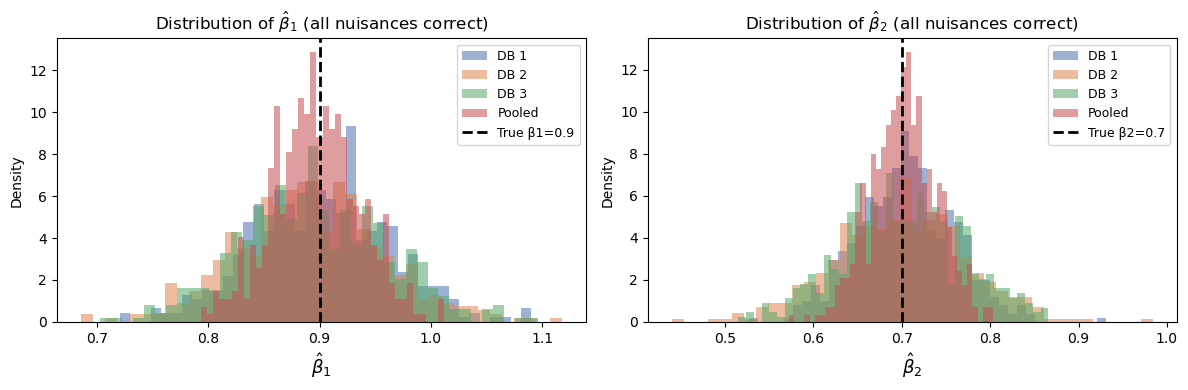

Saved meta_efficiency.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tags   = ['db1','db2','db3','ma']
labels = ['DB 1','DB 2','DB 3','Pooled']
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']

for ax, coef, truth, j in zip(axes, ['b1','b2'], [0.9, 0.7], [1, 2]):
    for tag, lbl, col in zip(tags, labels, colors):
        vals = partb_df[f'{tag}_{coef}'].values
        ax.hist(vals, bins=40, alpha=0.55, label=lbl, color=col, density=True)
    ax.axvline(truth, color='black', lw=2, ls='--', label=f'True β{j}={truth}')
    ax.set_xlabel(f'$\\hat{{\\beta}}_{j}$', fontsize=13)
    ax.set_ylabel('Density')
    ax.set_title(f'Distribution of $\\hat{{\\beta}}_{j}$ (all nuisances correct)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('meta_efficiency.png', dpi=150)
plt.show()
print('Saved meta_efficiency.png')

## 6. Part C — Meta-Analysis Robustness (one database misspecified)

We test three scenarios:
- **C1:** DB 1 has $m$ and $\pi$ both misspecified (DR fails for DB 1); DB 2, DB 3 all correct.
- **C2:** DB 2 has $\psi$ misspecified; DB 1, DB 3 all correct.
- **C3:** All three DBs have $m$ misspecified but $\pi$ correct (DR should still work per-DB).

We compare individual-DB DR estimates vs the IVW pooled estimate.

In [ ]:
correct   = {k: False for k in MISP_KEYS}
m_pi_bad  = {'misspecify_m': True, 'misspecify_pi': True,
             'misspecify_psi': False, 'misspecify_rho': False}
psi_bad   = {'misspecify_m': False, 'misspecify_pi': False,
             'misspecify_psi': True, 'misspecify_rho': False}
m_bad     = {'misspecify_m': True, 'misspecify_pi': False,
             'misspecify_psi': False, 'misspecify_rho': False}

partc_scenarios = {
    'C1: DB1 m+π bad, DB2 DB3 correct':    [m_pi_bad, correct,  correct],
    'C2: DB2 ψ bad, DB1 DB3 correct':       [correct,  psi_bad,  correct],
    'C3: All DBs m bad, π correct':          [m_bad,    m_bad,    m_bad],
}

partc_results = {}
for name, scen_list in partc_scenarios.items():
    print(f'Running {name} ...')
    recs = Parallel(n_jobs=-1, backend='threading')(
        delayed(_one_rep_meta)(i, N_OBS, 10_000, scen_list)
        for i in range(N_SIM)
    )
    partc_results[name] = pd.DataFrame(recs)

print('Part C done.')

Running C1: DB1 m+π bad, DB2 DB3 correct ...
Running C2: DB2 ψ bad, DB1 DB3 correct ...
Running C3: All DBs m bad, π correct ...
Part C done.


In [ ]:
for name, df in partc_results.items():
    tbl = efficiency_table(df)
    print(f'\n{"="*80}')
    print(f'  {name}')
    print(f'{"="*80}')
    print(tbl.to_string(float_format=lambda x: f'{x:+.4f}' if abs(x) < 1 else f'{x:.4f}'))


  C1: DB1 m+π bad, DB2 DB3 correct
              Bias(β1)  RMSE(β1)  Cov%(β1)  Bias(β2)  RMSE(β2)  Cov%(β2)
Estimator                                                               
DB 1           -0.0460   +0.0735   +0.8860   -0.0025   +0.0523   +0.9600
DB 2           -0.0018   +0.0659   +0.9480   +0.0002   +0.0687   +0.9600
DB 3           +0.0033   +0.0626   +0.9500   -0.0075   +0.0682   +0.9440
Pooled (IVW)   -0.0155   +0.0382   +0.9340   -0.0080   +0.0369   +0.9280

  C2: DB2 ψ bad, DB1 DB3 correct
              Bias(β1)  RMSE(β1)  Cov%(β1)  Bias(β2)  RMSE(β2)  Cov%(β2)
Estimator                                                               
DB 1           +0.0029   +0.0595   +0.9500   +0.0027   +0.0519   +0.9560
DB 2           -0.0020   +0.0689   +0.9480   +0.0025   +0.0702   +0.9600
DB 3           +0.0033   +0.0626   +0.9500   -0.0075   +0.0682   +0.9440
Pooled (IVW)   +0.0016   +0.0364   +0.9440   -0.0001   +0.0360   +0.9440

  C3: All DBs m bad, π correct
              Bias(β1)

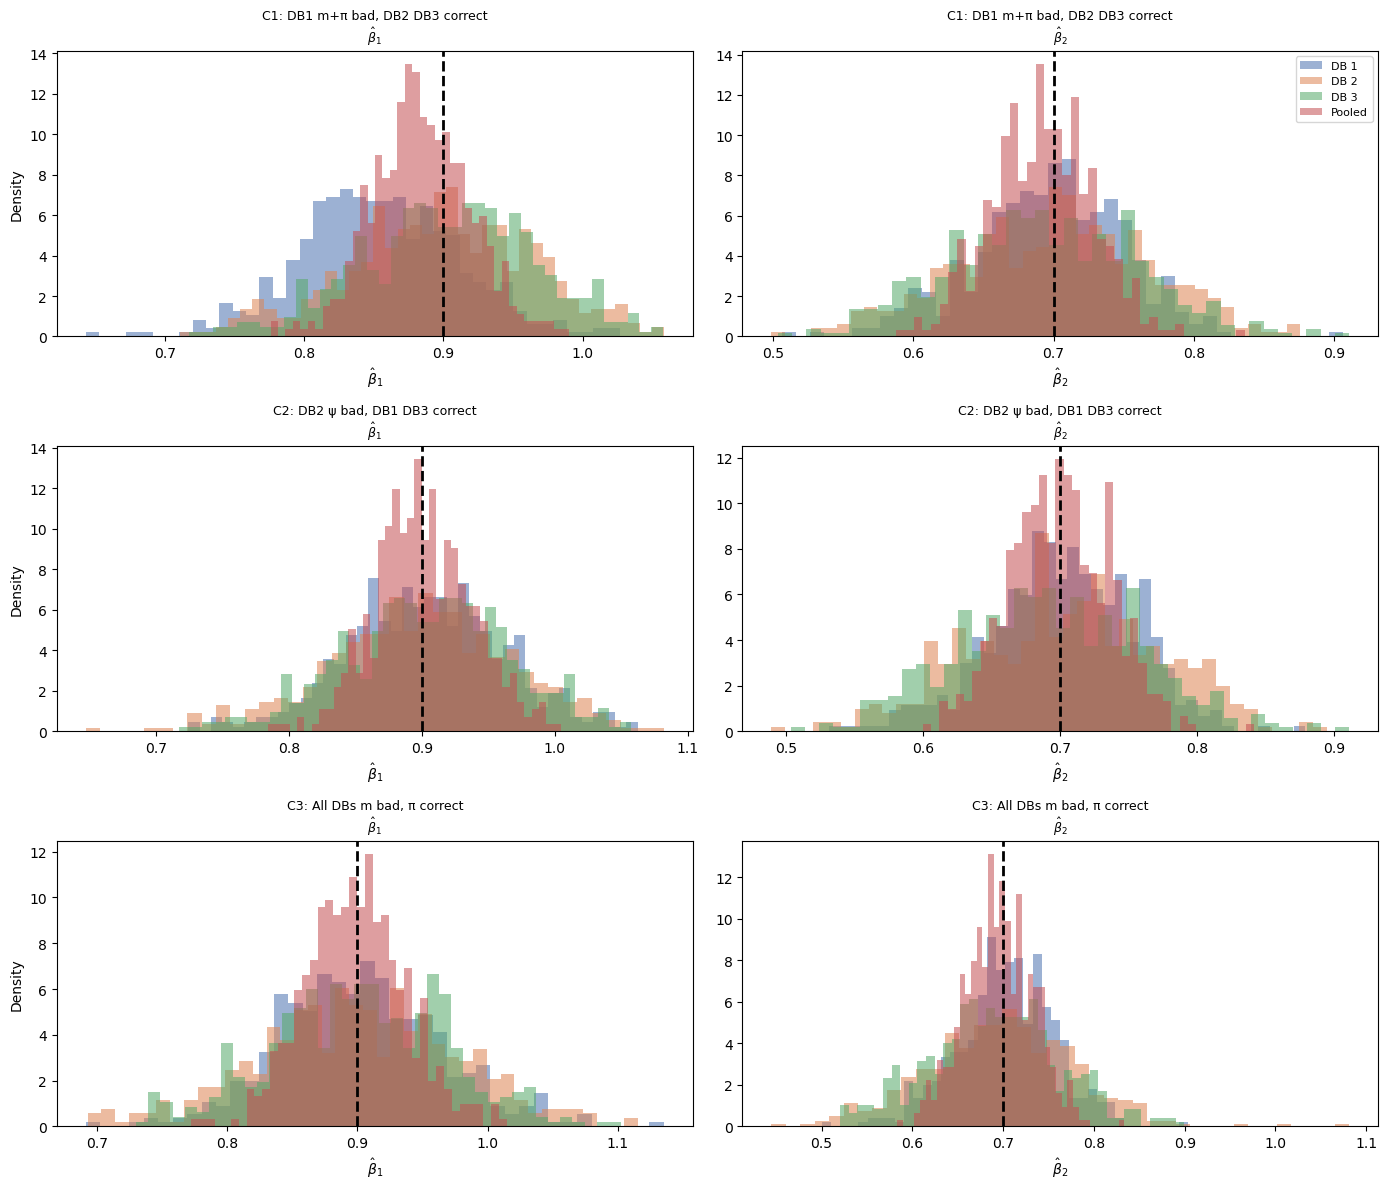

Saved meta_robustness.png


In [ ]:
fig, axes = plt.subplots(len(partc_scenarios), 2, figsize=(14, 4*len(partc_scenarios)))

for row_idx, (name, df) in enumerate(partc_results.items()):
    for col_idx, (coef, truth, j) in enumerate(zip(['b1','b2'],[0.9,0.7],[1,2])):
        ax = axes[row_idx, col_idx]
        for tag, lbl, col in zip(tags, labels, colors):
            ax.hist(df[f'{tag}_{coef}'].values, bins=40, alpha=0.55,
                    label=lbl, color=col, density=True)
        ax.axvline(truth, color='black', lw=2, ls='--')
        ax.set_title(f'{name}\n$\\hat{{\\beta}}_{j}$', fontsize=9)
        ax.set_xlabel(f'$\\hat{{\\beta}}_{j}$')
        if col_idx == 0:
            ax.set_ylabel('Density')
        if row_idx == 0 and col_idx == 1:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('meta_robustness.png', dpi=150)
plt.show()
print('Saved meta_robustness.png')

## 7. Summary

**Part A** confirms that the DR estimator satisfies the two-condition double robustness property
independently within each of the three heterogeneous databases.

**Part B** shows that IVW meta-analysis across the three databases yields a pooled estimate with
lower RMSE than any individual-database estimate, with nominal 95% CI coverage.

**Part C** demonstrates the meta-analysis is robust to single-database nuisance misspecification:
when only one of the three databases has misspecified nuisance functions, the pooled IVW
estimate retains approximate unbiasedness and near-nominal coverage, because the correctly
specified databases dominate via the inverse-variance weighting.